In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [33]:
ipums_path = os.path.expanduser('~/repoad688-employability-sum26-groupB/data/processed/employed_only.csv')
ipums = pd.read_csv(ipums_path)
print(f'Shape: {ipums.shape}')
print(f'\nColumns: {ipums.columns.tolist()}')
ipums.head(10)

Shape: (1572726, 13)

Columns: ['SERIAL', 'PERNUM', 'SEX', 'AGE', 'RACE', 'STATEFIP', 'OCC', 'IND', 'INCWAGE', 'PERWT', 'SEX_LABEL', 'RACE_LABEL', 'STATE_NAME']


,SERIAL,PERNUM,SEX,AGE,RACE,STATEFIP,OCC,IND,INCWAGE,PERWT,SEX_LABEL,RACE_LABEL,STATE_NAME
0,3800,1,1,64,1,1,8990,570,28000,11.00,Male,White,Alabama
1,3800,2,2,52,1,1,5740,8191,28000,12.00,Female,White,Alabama
2,3800,4,2,26,1,1,9141,6180,35200,15.00,Female,White,Alabama
3,3803,1,1,64,1,1,1010,9480,130000,199.00,Male,White,Alabama
4,3803,3,1,34,1,1,7240,7190,29100,208.00,Male,White,Alabama
5,3804,1,1,36,1,1,8140,2870,100000,69.00,Male,White,Alabama
6,3804,2,2,34,1,1,3500,8191,80000,65.00,Female,White,Alabama
7,3806,1,2,42,8,1,735,8290,150000,373.00,Female,Two races,Alabama
8,3807,1,2,37,1,1,2205,7870,15000,73.00,Female,White,Alabama
9,3807,2,1,41,2,1,5550,6370,73000,101.00,Male,Black,Alabama


In [34]:
print('Summary Statistics:')
ipums.describe(include='all')

Summary Statistics:


,SERIAL,PERNUM,SEX,AGE,RACE,STATEFIP,OCC,IND,INCWAGE,PERWT,SEX_LABEL,RACE_LABEL,STATE_NAME
count,"1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00",1572726,1572726,1572726
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,9,51
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,White,California
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,814215,1055852,183678
mean,"767,369.28",1.72,1.48,44.15,2.55,27.85,"3,909.96","6,393.94","68,391.03",106.07,NaN,NaN,NaN
std,"443,671.76",1.00,0.50,15.04,2.61,16.09,"2,710.91","2,599.67","82,490.59",94.82,NaN,NaN,NaN
min,"3,800.00",1.00,1.00,16.00,1.00,1.00,10.00,170.00,0.00,1.00,NaN,NaN,NaN
25%,"377,769.25",1.00,1.00,32.00,1.00,12.00,"1,555.00","4,971.00","24,000.00",52.00,NaN,NaN,NaN
50%,"760,904.50",1.00,1.00,44.00,1.00,27.00,"3,910.00","7,380.00","50,000.00",78.00,NaN,NaN,NaN
75%,"1,159,119.75",2.00,2.00,56.00,3.00,42.00,"5,510.00","8,191.00","85,000.00",126.00,NaN,NaN,NaN


In [35]:
missing = ipums.isnull().sum()
missing_pct = (missing / len(ipums) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} of {ipums.shape[1]}')
missing_df

Columns with missing values: 0 of 13


,Missing Count,Missing %


In [36]:
print('Gender Distribution:')
print(ipums['SEX_LABEL'].value_counts())
print()
print('Gender % Distribution:')
print((ipums['SEX_LABEL'].value_counts(normalize=True) * 100).round(2))

Gender Distribution:
SEX_LABEL
Male      814215
Female    758511
Name: count, dtype: int64

Gender % Distribution:
SEX_LABEL
Male     51.77
Female   48.23
Name: proportion, dtype: float64


In [37]:
zero_wage = ipums[ipums['INCWAGE'] == 0]
print(f'Records with $0 wage: {len(zero_wage):,}')
print(f'Percentage: {(len(zero_wage) / len(ipums) * 100):.2f}%')
print()
print('Gender breakdown of $0 wage:')
print(zero_wage['SEX_LABEL'].value_counts())

Records with $0 wage: 85,178
Percentage: 5.42%

Gender breakdown of $0 wage:
SEX_LABEL
Male      49117
Female    36061
Name: count, dtype: int64


In [38]:
print('Average wage INCLUDING $0:')
print(ipums.groupby('SEX_LABEL')['INCWAGE'].mean().round(2))

print('\nAverage wage EXCLUDING $0:')
ipums_nonzero = ipums[ipums['INCWAGE'] > 0]
print(ipums_nonzero.groupby('SEX_LABEL')['INCWAGE'].mean().round(2))
print(f'\nRows remaining after removing $0: {len(ipums_nonzero):,}')

Average wage INCLUDING $0:
SEX_LABEL
Female   56,730.36
Male     79,253.95
Name: INCWAGE, dtype: float64

Average wage EXCLUDING $0:
SEX_LABEL
Female   59,562.05
Male     84,341.82
Name: INCWAGE, dtype: float64

Rows remaining after removing $0: 1,487,548


In [39]:
ipums_clean = ipums[ipums['INCWAGE'] > 0].copy()
print(f'Clean dataset shape: {ipums_clean.shape}')
print(f'Removed {len(ipums) - len(ipums_clean):,} rows with $0 wage')

Clean dataset shape: (1487548, 13)
Removed 85,178 rows with $0 wage


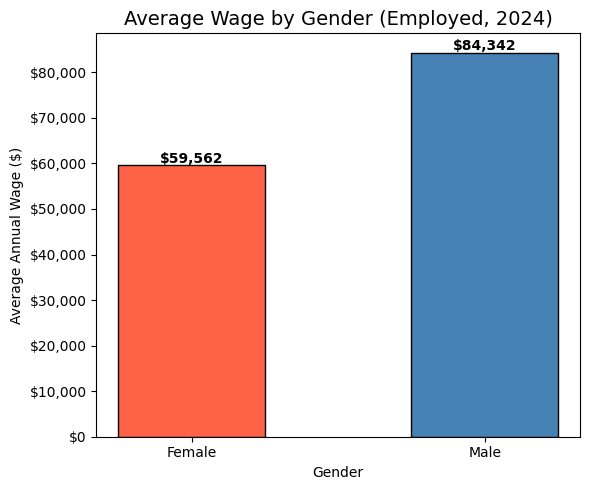

In [40]:
avg_wage = ipums_clean.groupby('SEX_LABEL')['INCWAGE'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(avg_wage['SEX_LABEL'], avg_wage['INCWAGE'],
              color=['tomato', 'steelblue'], edgecolor='black', width=0.5)

ax.set_title('Average Wage by Gender (Employed, 2024)', fontsize=14)
ax.set_xlabel('Gender')
ax.set_ylabel('Average Annual Wage ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val in zip(bars, avg_wage['INCWAGE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [41]:
clean_path = os.path.expanduser('~/repoad688-employability-sum26-groupB/data/clean/')
os.makedirs(clean_path, exist_ok=True)

output_path = f'{clean_path}employed_only_clean.csv'
ipums_clean.to_csv(output_path, index=False)
print(f'Saved to: {output_path}')
print(f'Shape: {ipums_clean.shape}')

Saved to: /home/ubuntu/repoad688-employability-sum26-groupB/data/clean/employed_only_clean.csv
Shape: (1487548, 13)
